### Image Compression using KMeans Clustering

Quantization, involved in image processing, is a lossy compression technique achieved by compressing a range of values to a single quantum (discrete) value. When the number of discrete symbols in a given stream is reduced, the stream becomes more compressible.

#### 1) Importing Necessary Libraries:

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as img

from sklearn.cluster import KMeans

#### 2) Reading Image as an 3D-Array and Reshaping:

##### 1) Reading Image as an Array:

In [3]:
image = img.imread('Doctor Strange 3.jpg')

In [4]:
image

array([[[ 98, 113, 144],
        [ 89, 104, 135],
        [ 86, 101, 134],
        ...,
        [138, 148, 173],
        [153, 160, 179],
        [153, 158, 177]],

       [[ 95, 106, 134],
        [ 93, 106, 138],
        [ 84, 100, 133],
        ...,
        [148, 154, 176],
        [154, 159, 179],
        [150, 155, 174]],

       [[ 97, 108, 138],
        [ 97, 108, 138],
        [ 86, 101, 132],
        ...,
        [150, 156, 178],
        [159, 164, 184],
        [146, 152, 176]],

       ...,

       [[ 96, 126, 164],
        [ 98, 128, 166],
        [100, 127, 170],
        ...,
        [ 95, 121, 158],
        [101, 127, 164],
        [105, 131, 168]],

       [[ 93, 123, 161],
        [ 94, 123, 163],
        [ 95, 127, 168],
        ...,
        [ 91, 116, 157],
        [ 91, 116, 157],
        [101, 126, 167]],

       [[ 92, 120, 160],
        [ 94, 122, 162],
        [ 86, 118, 157],
        ...,
        [ 94, 119, 159],
        [ 86, 111, 152],
        [101, 126, 167]]

In [5]:
image.shape

(1080, 1920, 3)

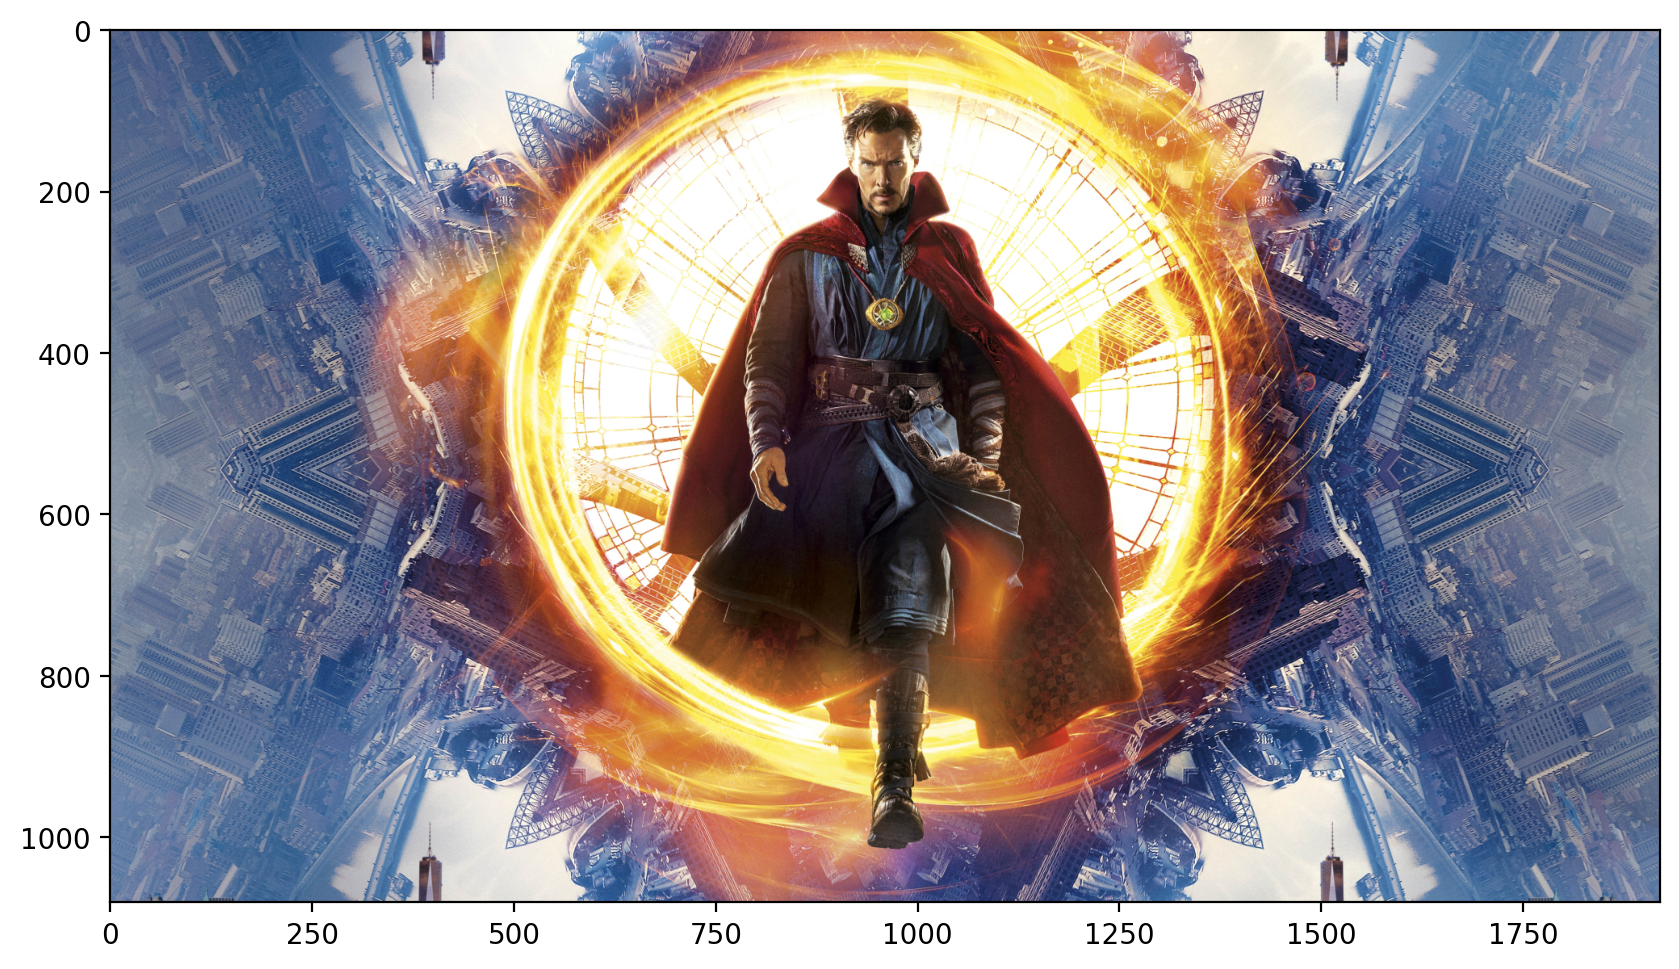

In [6]:
# Visualizing The Image:

plt.figure(figsize= (10, 8), dpi= 200)
plt.imshow(image)
plt.show()

##### 2) Reshaping Array:

In [7]:
image.shape

(1080, 1920, 3)

- This Shape represents (Height, Width, Colours) of Image.
- Reshaping Array from (Height, Width, Colours) (3D) to (Height * Width, Colours) (2D)

In [8]:
(Height, Width, Colours) = image.shape

In [9]:
print(Height, Width, Colours)

1080 1920 3


In [10]:
# Converting Image Array from 3D to 2D:

image_2d = image.reshape(Height * Width, Colours)

In [11]:
image_2d.shape

(2073600, 3)

In [12]:
image_2d

array([[ 98, 113, 144],
       [ 89, 104, 135],
       [ 86, 101, 134],
       ...,
       [ 94, 119, 159],
       [ 86, 111, 152],
       [101, 126, 167]], shape=(2073600, 3), dtype=uint8)

#### 3) Compression Using KMeans:

In [13]:
kmc = KMeans(n_clusters= 5)
clusters = kmc.fit_predict(image_2d)
clusters

array([4, 1, 1, ..., 4, 4, 4], shape=(2073600,), dtype=int32)

In [14]:
kmc.cluster_centers_

array([[244.29868667, 239.97453023, 221.95585011],
       [ 69.59094041,  86.18758108, 126.08215828],
       [219.46067842, 158.95654655,  82.72061706],
       [ 72.42754563,  41.68851556,  39.6564491 ],
       [120.70778737, 129.27615855, 155.34648117]])

- Rounding Up Values of Cluster Centers so they can be used as colour values.

In [15]:
color_codes = np.round(kmc.cluster_centers_, 0)
color_codes

array([[244., 240., 222.],
       [ 70.,  86., 126.],
       [219., 159.,  83.],
       [ 72.,  42.,  40.],
       [121., 129., 155.]])

In [16]:
color_codes = color_codes.astype('int')
color_codes

array([[244, 240, 222],
       [ 70,  86, 126],
       [219, 159,  83],
       [ 72,  42,  40],
       [121, 129, 155]])

- Replacing Each Row in 2D array by the Value of Cluster Center that Row belongs to:

In [18]:
new_image_2d = color_codes[clusters]

In [19]:
new_image_2d

array([[121, 129, 155],
       [ 70,  86, 126],
       [ 70,  86, 126],
       ...,
       [121, 129, 155],
       [121, 129, 155],
       [121, 129, 155]], shape=(2073600, 3))

In [21]:
# Reshaping 2D Array to 3D:

new_image_3d = new_image_2d.reshape(Height, Width, Colours)

In [22]:
new_image_3d

array([[[121, 129, 155],
        [ 70,  86, 126],
        [ 70,  86, 126],
        ...,
        [121, 129, 155],
        [121, 129, 155],
        [121, 129, 155]],

       [[ 70,  86, 126],
        [ 70,  86, 126],
        [ 70,  86, 126],
        ...,
        [121, 129, 155],
        [121, 129, 155],
        [121, 129, 155]],

       [[121, 129, 155],
        [121, 129, 155],
        [ 70,  86, 126],
        ...,
        [121, 129, 155],
        [121, 129, 155],
        [121, 129, 155]],

       ...,

       [[121, 129, 155],
        [121, 129, 155],
        [121, 129, 155],
        ...,
        [121, 129, 155],
        [121, 129, 155],
        [121, 129, 155]],

       [[121, 129, 155],
        [121, 129, 155],
        [121, 129, 155],
        ...,
        [121, 129, 155],
        [121, 129, 155],
        [121, 129, 155]],

       [[121, 129, 155],
        [121, 129, 155],
        [121, 129, 155],
        ...,
        [121, 129, 155],
        [121, 129, 155],
        [121, 129, 155]]

In [23]:
new_image_3d.shape

(1080, 1920, 3)

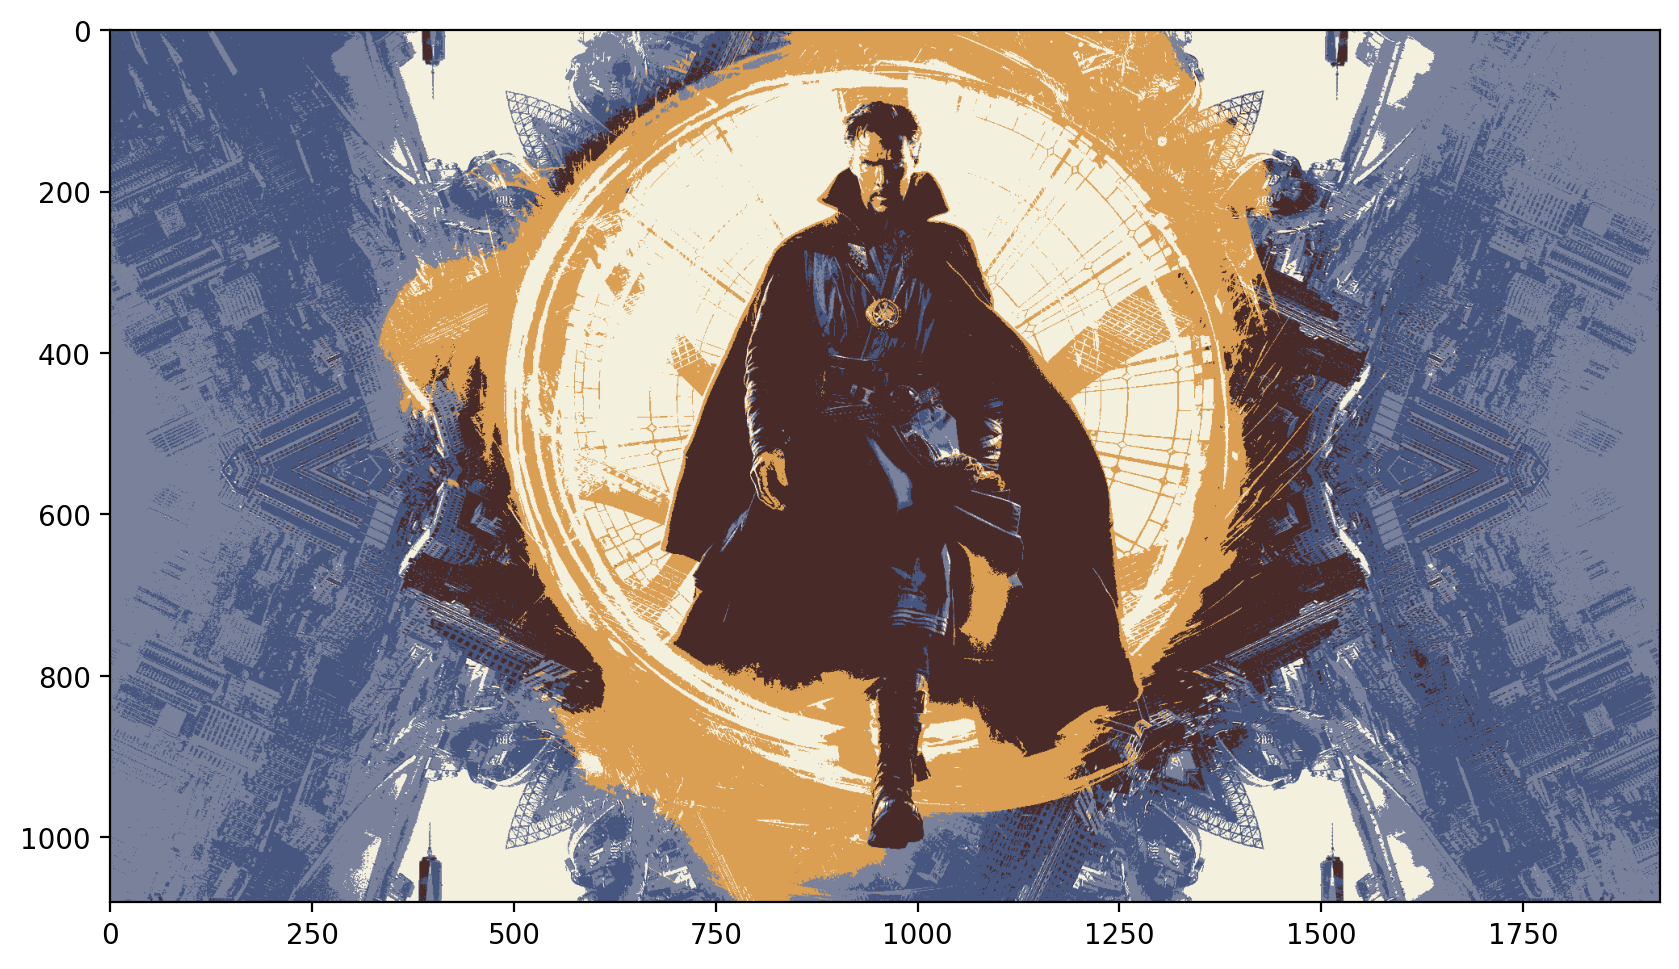

In [24]:
# Visualizing New Image:

plt.figure(figsize= (10, 8), dpi= 200)
plt.imshow(new_image_3d)
plt.show()